## Figure 12 Reproduction: All 8 Slabs

This notebook trains the **Proposed 1D CNN** using Leave-One-Specimen-Out (LOSO) cross-validation and generates the 2D coordinate-based contour maps exactly as seen in Figure 12 of the paper.

**Fixes Applied for Article Parity:**
1. **Model Weights:** The plotting function is now executed *inside* the training loop. This guarantees that the CNN map for Slab `i` uses the exact model weights trained on the other 7 slabs.
2. **Contour Smoothing:** Replaced `tricontourf` with `scipy.interpolate.griddata` to mimic the smooth, continuous color boundaries seen in the paper.
3. **FFT Noise Guard:** Bounded the peak frequency search between 1 kHz and 20 kHz to prevent high-frequency noise artifacts from skewing the Conventional colormap.
4. **Axes & Contours:** Adjusted X and Y boundaries to have a 0.1m margin and forced the peak frequency contour bands to display as integers.

In [1]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.signal.windows import blackmanharris
from scipy.fft import fft, fftfreq
from scipy.interpolate import griddata

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix

c:\Users\kairen.shen.ctr\.conda\envs\bsm\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


### 1. Data Aggregation & Logic Functions
Aggregating the testing data and establishing the parser to convert filename conventions (e.g., `D-6.txt`) into structural X,Y coordinates.

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================
# File Parsing & Dataset Preparation
# ==========================================
base_dir = r"C:\Users\kairen.shen.ctr\My Drive\4 IE reproduce\testing data"

all_filepaths = []
all_labels = []
all_slab_ids = []

for slab_id in range(1, 9):
    slab_folder = os.path.join(base_dir, f"Slab{slab_id}")
    for defect_type, label in [("D", 1), ("S", 0)]:
        folder = os.path.join(slab_folder, defect_type)
        if os.path.exists(folder):
            for file in os.listdir(folder):
                if file.endswith(".txt"):
                    all_filepaths.append(os.path.join(folder, file))
                    all_labels.append(label)
                    all_slab_ids.append(slab_id)

all_filepaths = np.array(all_filepaths)
all_labels = np.array(all_labels)
all_slab_ids = np.array(all_slab_ids)

class IEDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        df = pd.read_csv(self.file_paths[idx], sep=r'\s+', header=None, names=['Time', 'Voltage'])
        voltage = df['Voltage'].values.astype(np.float32)
        voltage = (voltage - np.mean(voltage)) / (np.std(voltage) + 1e-8)
        return torch.tensor(voltage).unsqueeze(-1), torch.tensor(self.labels[idx], dtype=torch.long)

def parse_filename_to_coords(filename):
    basename = os.path.basename(filename)
    match = re.search(r'([A-Z])-(\d+)', basename)
    if not match:
        return None, None
    letter = match.group(1)
    number = int(match.group(2))
    y = (ord(letter) - ord('A') + 1) * 0.05
    x = number * 0.05
    return x, y

def get_peak_frequency(voltage_signal, sample_rate=200000.0):
    N = len(voltage_signal)
    T = 1.0 / sample_rate
    w = blackmanharris(N)
    yf = fft(voltage_signal * w)
    xf = fftfreq(N, T)[:N//2]
    amp = np.abs(yf[0:N//2])
    
    # Bound between 1kHz and 20kHz to prevent artifacts
    valid_idx = np.where((xf > 1000) & (xf < 20000))[0]
    if len(valid_idx) == 0: return 0.0
    peak_idx = valid_idx[np.argmax(amp[valid_idx])]
    return xf[peak_idx] / 1000.0

Using device: cuda


### 2. Plotting Logic (Grid Interpolation)
This interpolates the sparse (X,Y) signals into a dense, smooth heatmap mirroring the visual style of the paper.

In [3]:
def draw_true_defects(ax):
    x_intervals = [(0.3, 0.6), (0.9, 1.2), (1.8, 2.1), (2.4, 2.7)]
    y_intervals = [(0.15, 0.35), (0.65, 0.85)]
    for (x_start, x_end) in x_intervals:
        for (y_start, y_end) in y_intervals:
            width, height = x_end - x_start, y_end - y_start
            rect = patches.Rectangle((x_start, y_start), width, height, 
                                     linewidth=2.5, edgecolor='white', facecolor='none', linestyle='--')
            ax.add_patch(rect)

def plot_defect_maps(x_coords, y_coords, peak_freqs, cnn_probs, specimen_name="S1"):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Generate fine grid bounded by 0.1 and 2.9 (X) and 0.1 and 0.9 (Y)
    xi = np.linspace(0.1, 2.9, 300)
    yi = np.linspace(0.1, 0.9, 100)
    XI, YI = np.meshgrid(xi, yi)
    
    # Interpolate Peak Frequency (Conventional)
    ZI_freq = griddata((x_coords, y_coords), peak_freqs, (XI, YI), method='linear')
    ZI_freq_near = griddata((x_coords, y_coords), peak_freqs, (XI, YI), method='nearest')
    ZI_freq[np.isnan(ZI_freq)] = ZI_freq_near[np.isnan(ZI_freq)]  # Fill edges
    ZI_freq = np.clip(ZI_freq, 2, 11)  # Clip to paper's colorbar range

    # Interpolate Probability (1D CNN)
    ZI_prob = griddata((x_coords, y_coords), cnn_probs, (XI, YI), method='linear')
    ZI_prob_near = griddata((x_coords, y_coords), cnn_probs, (XI, YI), method='nearest')
    ZI_prob[np.isnan(ZI_prob)] = ZI_prob_near[np.isnan(ZI_prob)]
    ZI_prob = np.clip(ZI_prob, 0, 1)

    # 1. Conventional Peak Frequency Map
    ax1 = axes[0]
    # Using integers 2 to 11 for the discrete contour levels
    cf1 = ax1.contourf(XI, YI, ZI_freq, levels=np.arange(2, 12), cmap='jet_r', extend='both')
    ax1.set_title(f"{specimen_name} (CONVENTIONAL)", fontsize=15, fontweight='bold', loc='left')
    ax1.set_xlabel("Longitudinal distance (m)", fontsize=11)
    ax1.set_ylabel("Lateral distance (m)", fontsize=11)
    ax1.set_xlim(0.1, 2.9)
    ax1.set_ylim(0.1, 0.9)
    draw_true_defects(ax1)
    # Forcing colorbar ticks to strictly be integers
    cbar1 = fig.colorbar(cf1, ax=ax1, pad=0.01, ticks=np.arange(2, 12))
    cbar1.set_label("Peak Frequency Value (kHz)", fontsize=11)
    
    # 2. 1D CNN Probability Map
    ax2 = axes[1]
    cf2 = ax2.contourf(XI, YI, ZI_prob, levels=np.linspace(0, 1.0, 11), cmap='jet')
    ax2.set_title(f"{specimen_name} (1D CNN)", fontsize=15, fontweight='bold', loc='left')
    ax2.set_xlabel("Longitudinal distance (m)", fontsize=11)
    ax2.set_ylabel("Lateral distance (m)", fontsize=11)
    ax2.set_xlim(0.1, 2.9)
    ax2.set_ylim(0.1, 0.9)
    draw_true_defects(ax2)
    cbar2 = fig.colorbar(cf2, ax=ax2, pad=0.01)
    cbar2.set_label("Probability of Defect Presence", fontsize=11)
    
    plt.tight_layout()
    plt.show()

def generate_maps_for_specimen(model, test_files, test_dataset, specimen_name="S1"):
    model.eval()
    x_coords, y_coords, peak_freqs, cnn_probs = [], [], [], []
    
    with torch.no_grad():
        for i in range(len(test_dataset)):
            filepath = test_files[i]
            x, y = parse_filename_to_coords(filepath)
            if x is None or y is None: continue
                
            x_coords.append(x)
            y_coords.append(y)
            
            # Conventional Logic
            df = pd.read_csv(filepath, sep=r'\s+', header=None, names=['Time', 'Voltage'])
            peak_freqs.append(get_peak_frequency(df['Voltage'].values))
            
            # 1D CNN Inference
            tensor_input, _ = test_dataset[i]
            logits = model(tensor_input.unsqueeze(0).to(device))
            probs = F.softmax(logits, dim=1)
            cnn_probs.append(probs[0, 1].item()) # Class 1 (Defected)
            
    plot_defect_maps(x_coords, y_coords, peak_freqs, cnn_probs, specimen_name)

### 3. Model Definition
The provided `1D CNN` architecture matching Figure 6 of the paper.

In [4]:
class IE_1D_CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(IE_1D_CNN, self).__init__()
        self.cbr1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=20, kernel_size=200, padding='same'),
            nn.BatchNorm1d(20),
            nn.ReLU()
        )
        self.mp1 = nn.MaxPool1d(kernel_size=10, stride=10) 
        self.cbr2 = nn.Sequential(
            nn.Conv1d(in_channels=20, out_channels=200, kernel_size=2, padding='valid'),
            nn.BatchNorm1d(200),
            nn.ReLU()
        )
        self.mp2 = nn.MaxPool1d(kernel_size=2, stride=2) 
        self.cbr3 = nn.Sequential(
            nn.Conv1d(in_channels=200, out_channels=200, kernel_size=4, padding='valid'),
            nn.BatchNorm1d(200),
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.frd1 = nn.Sequential(
            nn.Linear(19200, 1000),
            nn.ReLU(),
            nn.Dropout(p=0.5) 
        )
        self.frd2 = nn.Sequential(
            nn.Linear(1000, 500),
            nn.ReLU(),
            nn.Dropout(p=0.5)
        )
        self.output_layer = nn.Linear(500, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cbr1(x)
        x = self.mp1(x)
        x = self.cbr2(x)
        x = self.mp2(x)
        x = self.cbr3(x)
        x = self.flatten(x)
        x = self.frd1(x)
        x = self.frd2(x)
        return self.output_layer(x)

### 4. Full Execution (Cross-Validation + Figure Generation)
Runs the Leave-One-Specimen-Out training. At the end of each training loop, it dynamically invokes the map generator so the model evaluated on `Slab i` is strictly the one trained on `Slabs ~i`.

TRAINING & GENERATING MAP FOR SLAB 1


C:\Users\kairen.shen.ctr\AppData\Roaming\Python\Python39\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv1d(


Training complete. Generating Figure 12 map for S1...


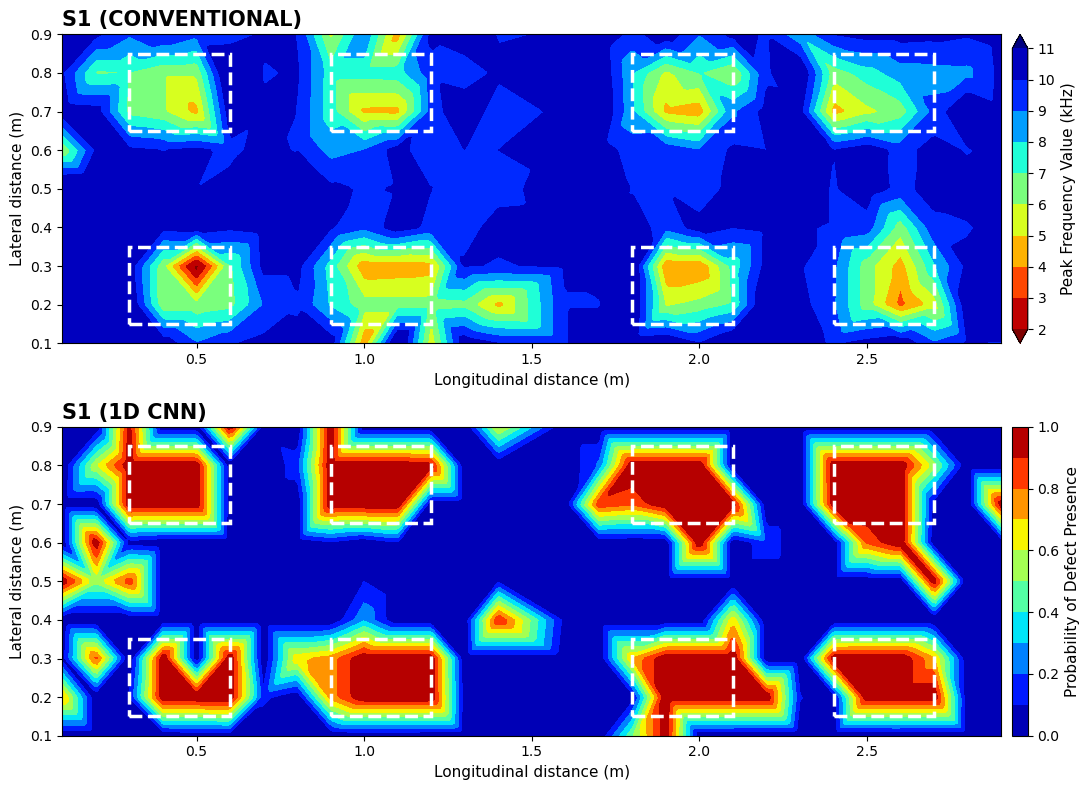



TRAINING & GENERATING MAP FOR SLAB 2
Training complete. Generating Figure 12 map for S2...


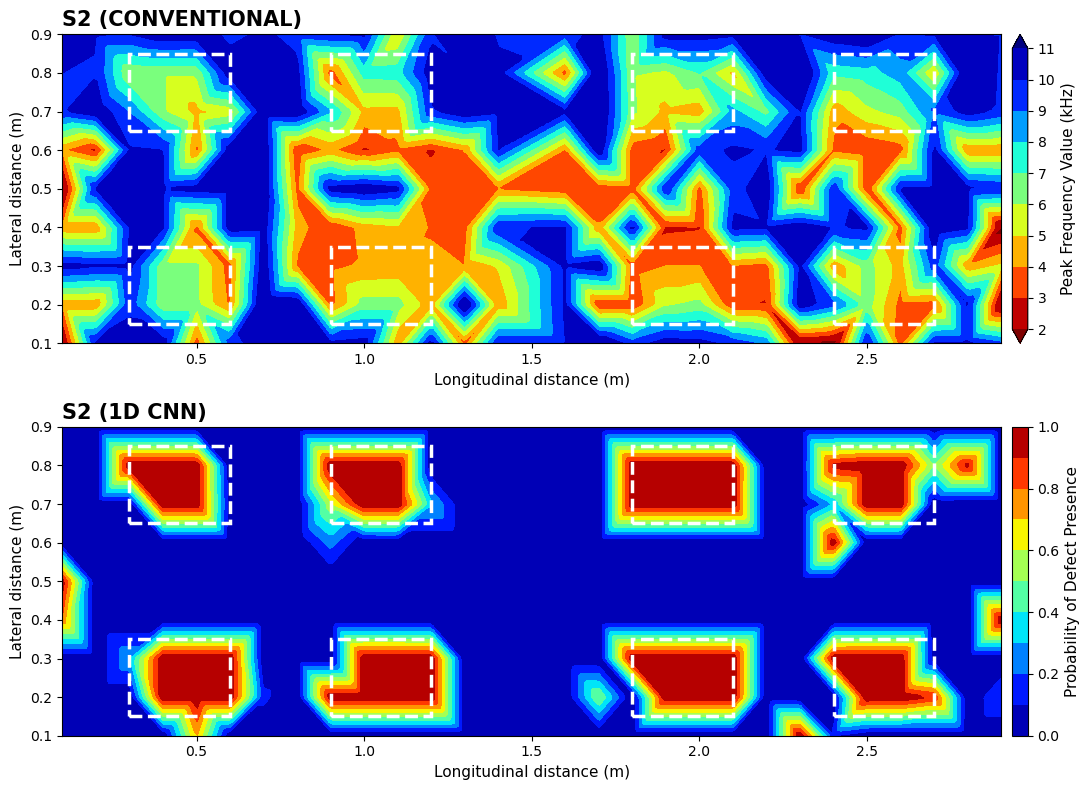



TRAINING & GENERATING MAP FOR SLAB 3
Training complete. Generating Figure 12 map for S3...


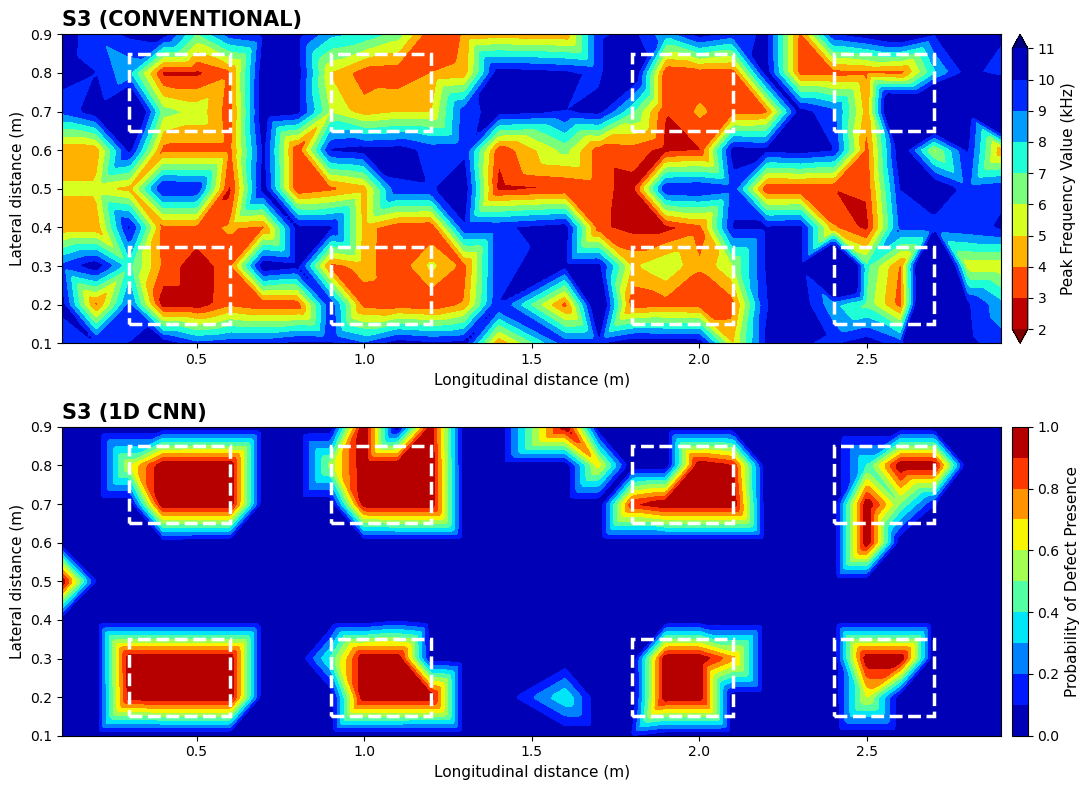



TRAINING & GENERATING MAP FOR SLAB 4
Training complete. Generating Figure 12 map for S4...


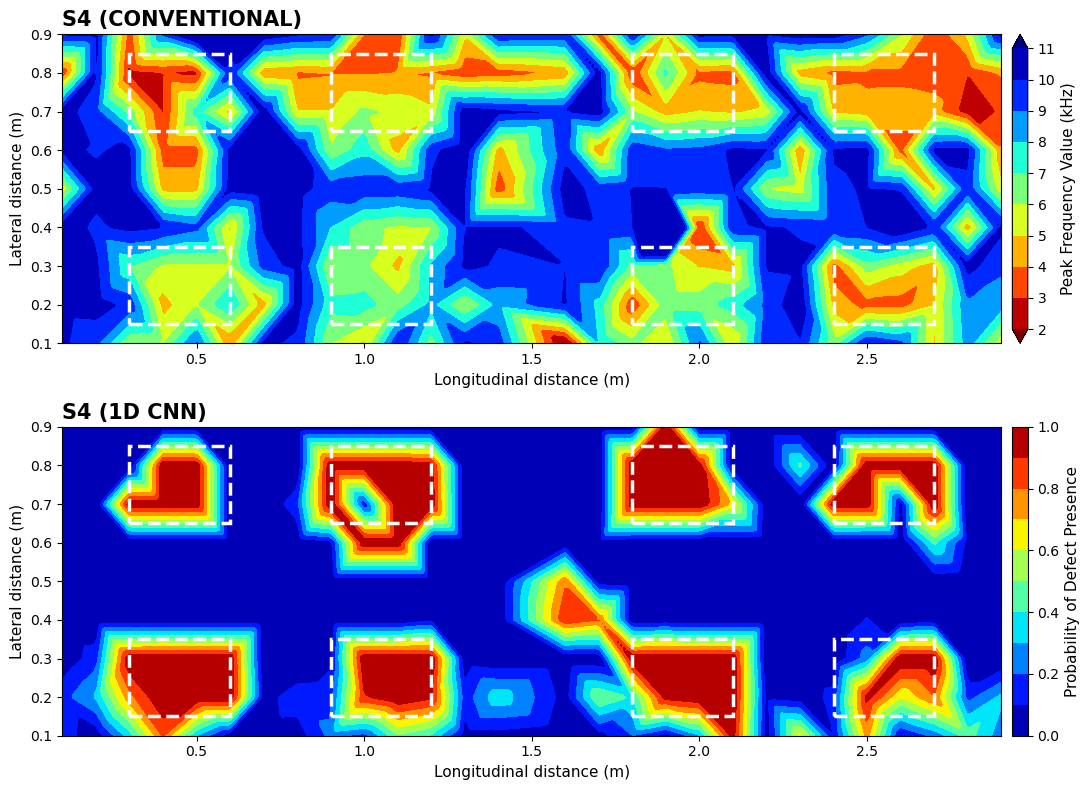



TRAINING & GENERATING MAP FOR SLAB 5
Training complete. Generating Figure 12 map for S5...


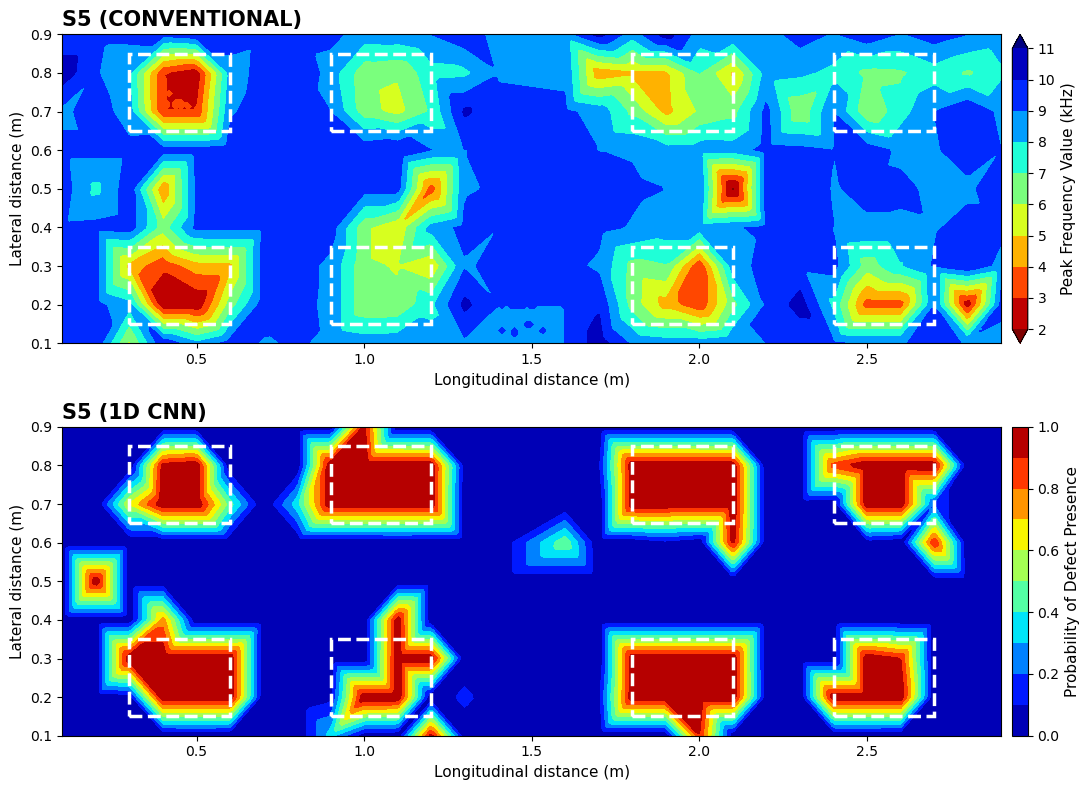



TRAINING & GENERATING MAP FOR SLAB 6
Training complete. Generating Figure 12 map for S6...


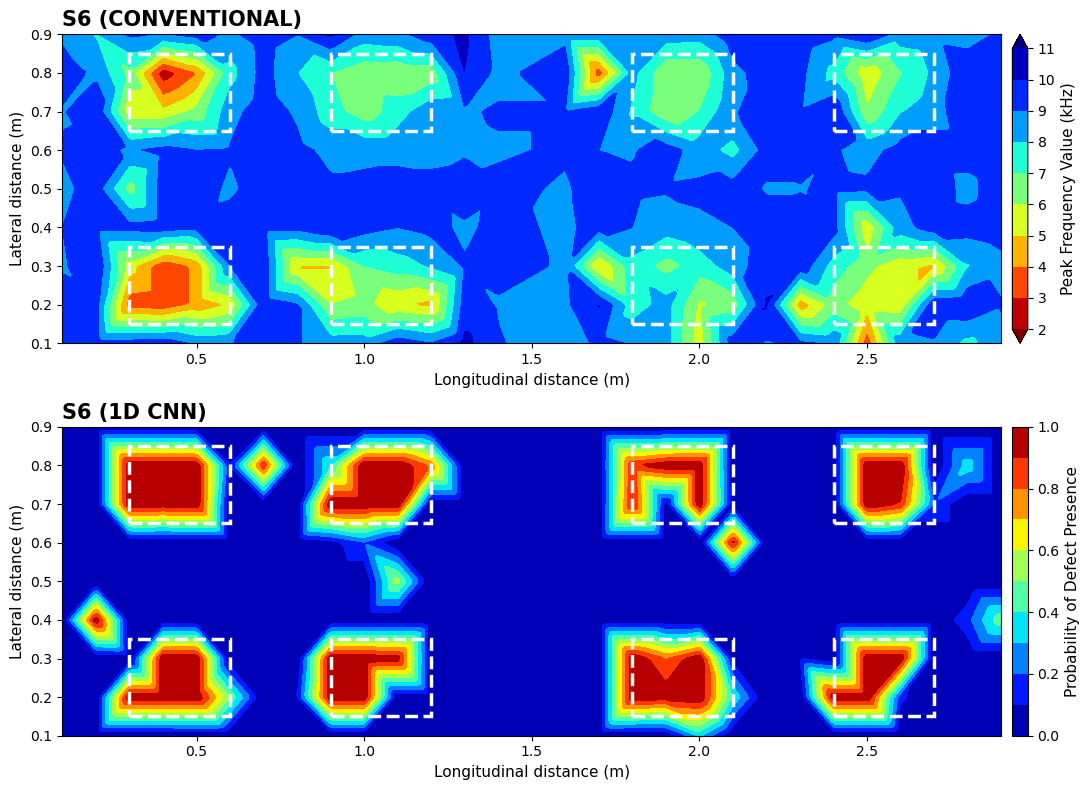



TRAINING & GENERATING MAP FOR SLAB 7
Training complete. Generating Figure 12 map for S7...


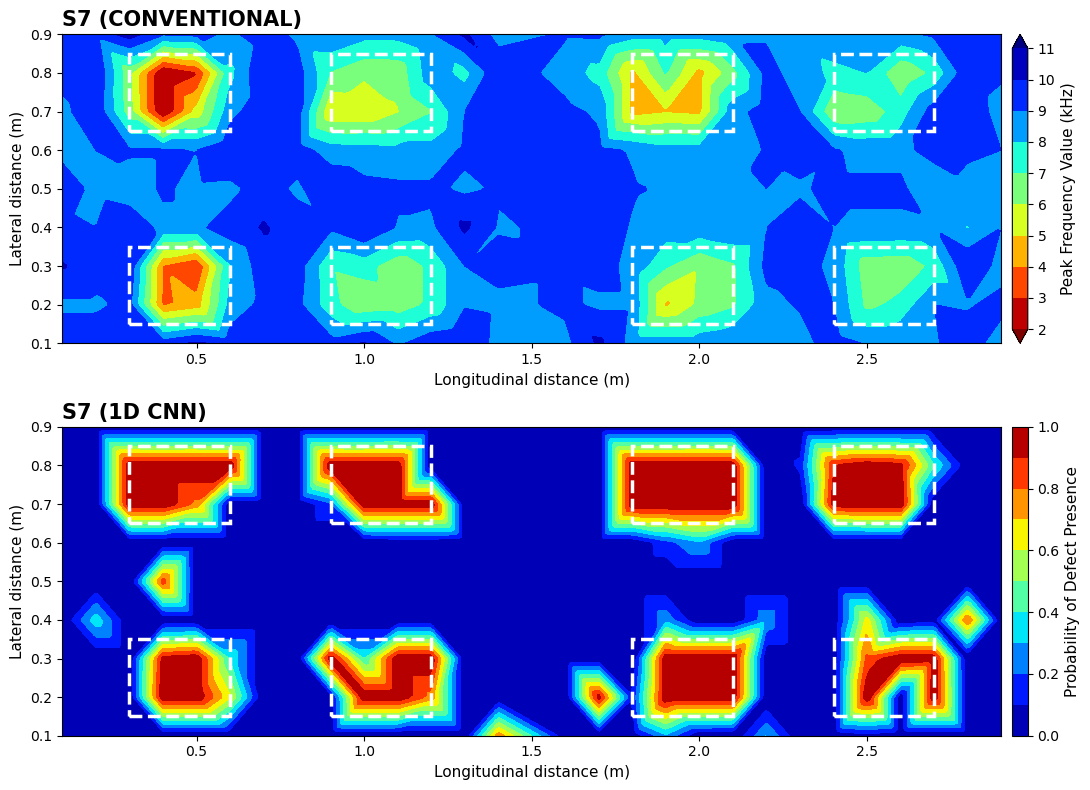



TRAINING & GENERATING MAP FOR SLAB 8
Training complete. Generating Figure 12 map for S8...


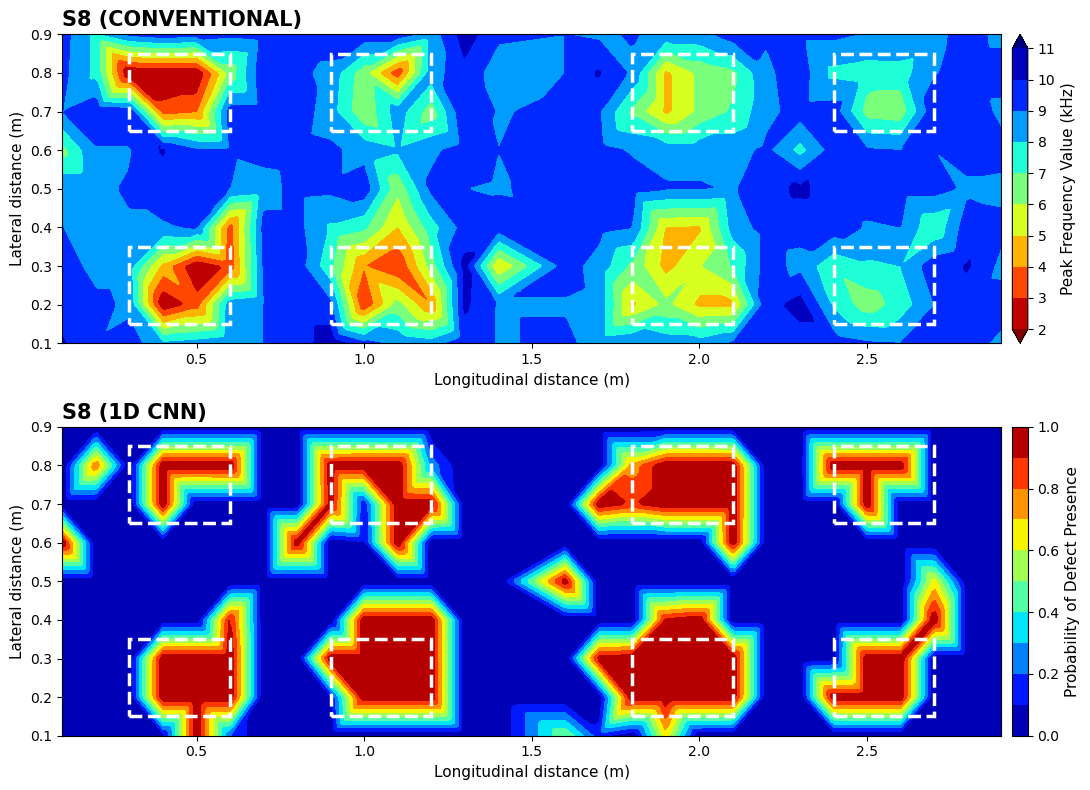

In [5]:
EPOCHS = 40
BATCH_SIZE = 50
LR = 1e-3
MOMENTUM = 0.9 

# Main Loop for all 8 slabs
for test_slab in range(1, 9):
    print("="*60)
    print(f"TRAINING & GENERATING MAP FOR SLAB {test_slab}")
    print("="*60)
    
    # Split data
    train_idx = np.where(all_slab_ids != test_slab)[0]
    test_idx = np.where(all_slab_ids == test_slab)[0]
    
    train_files, train_labels = all_filepaths[train_idx], all_labels[train_idx]
    test_files, test_labels = all_filepaths[test_idx], all_labels[test_idx]
    
    train_dataset = IEDataset(train_files, train_labels)
    test_dataset = IEDataset(test_files, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
    
    # Initialize Model
    model = IE_1D_CNN().to(device)
    
    # Imbalance Weighting
    weight_ratio = np.sum(train_labels == 0) / np.sum(train_labels == 1)
    class_weights = torch.tensor([1.0, weight_ratio], dtype=torch.float32).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)
    
    # Fast Training Loop
    for epoch in range(EPOCHS):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
    print(f"Training complete. Generating Figure 12 map for S{test_slab}...")
    
    # ---------- MAP GENERATION ---------- #
    # We call the generation function here while the model holds the exact Slabs~i weights!
    generate_maps_for_specimen(model, test_files, test_dataset, specimen_name=f"S{test_slab}")
    print("\n")